## Почему нужны обучаемые веса?

Веса, которые мы получили в прошлый раз, возникли сами собой, просто из-за схожести исходных чисел. Модель не могла ими управлять. Она не знала, что для местоимения «он» важнее существительное, а не прилагательное.

Представьте, что веса внимания - это громкость радиоканалов. В прошлой главе мы могли только слушать то, что играет. А теперь нам нужны **крутилки настройки**, чтобы мы могли сами решить: «Ага, канал существительных нужно сделать громче, а канал прилагательных - тише».

Без этих «крутилок» модель обречена угадывать связи случайно, основываясь лишь на первоначальной схожести слов.

**Пример:**

*«Кот любил сметану, потому что он был вкусный»*

Вопрос: к чему относится «он»?

* К коту? (кот был вкусный? странно...)
* К сметане? (сметана была вкусная? логично!)

В упрощённой версии «он» будет уделять внимание всем словам пропорционально схожести векторов. Но модель не может научиться, что для местоимений важно обращать внимание на существительные, а не на прилагательные.

И как же научить модель понимать, что «он» относится к сметане?

Чтобы решить эту проблему, мы добавим обучаемые веса. Именно они превратят наш учебный пример в полноценный механизм, используемый в GPT и BERT.

## Обучаемые матрицы $W_Q, W_K, W_V$

Мы добавим три матрицы весов, которые модель будет обучать на данных:

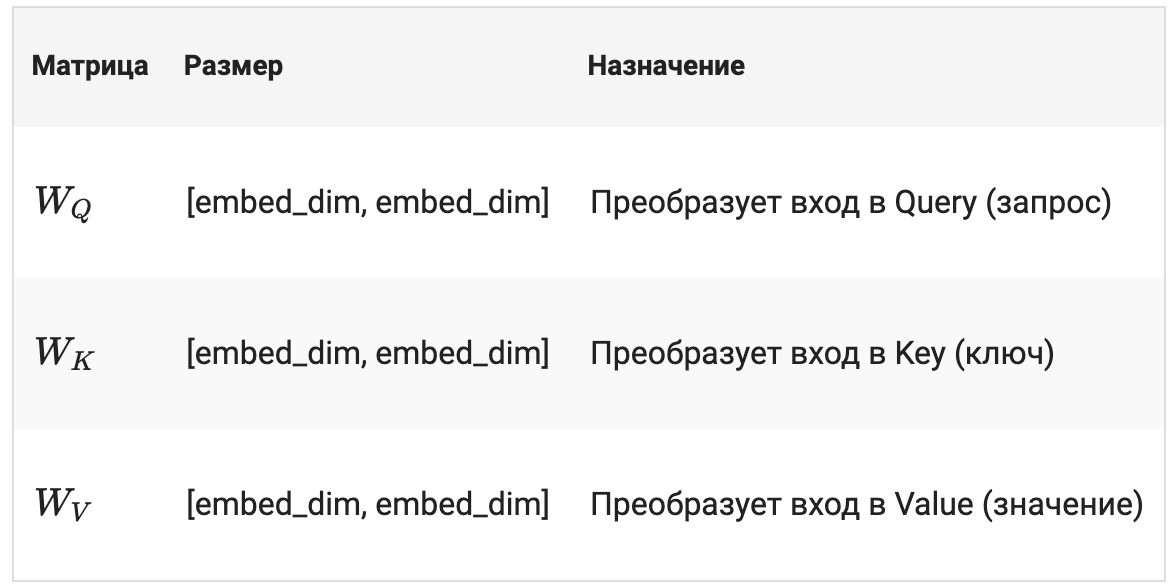

Формулы:

$$
\begin{aligned}
Q &= x \mathbin{@} W_Q \\
K &= x \mathbin{@} W_K \\
V &= x \mathbin{@} W_V
\end{aligned}
$$

Теперь модель может научиться:

* Какие связи важны (через $W_Q$ и $W_K$)
* Какую информацию передавать (через $W_V$)

**Зачем нам ТРИ разные матрицы?**

Может возникнуть вопрос: *«Почему нельзя использовать одну общую матрицу для всего? Или почему Query, Key и Value должны быть разными?»*

Ответ кроется в разделении ролей. Представьте себе работу библиотеки или системы поиска знакомств. У каждого участника процесса своя уникальная задача:

1. **Query ($Q$) - «Вопрос» или «Поисковый запрос»**
    * **Роль:** Это активная часть. Когда слово (токен) обрабатывается, его вектор $Q$ отвечает на вопрос: **«Что я ищу? На какие другие слова мне нужно обратить внимание прямо сейчас?»**
    * **Аналогия:** Представьте, что вы ищете книгу в библиотеке. Ваш запрос $Q$ - это название темы, которая вас интересует (например, «история Рима»).
    * **Зачем обучать:** Модель должна научиться формулировать правильные вопросы. Для местоимения «он» матрица $W_Q$ должна преобразовать входной вектор так, чтобы вопрос звучал как: «Где здесь ближайшее существительное мужского рода?», а не просто «Где похожие слова?».

2. **Key ($K$) - «Метка» или «Адрес»**
    * **Роль:** Это пассивная часть. Вектор $K$ каждого слова отвечает на вопрос: **«Чем я могу быть полезен? На какой запрос я отвечаю?»**
    * **Аналогия:** Это корешок книги на полке с надписью «История Рима». Библиотекарь сравнивает ваш запрос $Q$ с корешками книг ($K$). Если они совпадают - книга найдена.
    * **Зачем обучать:** Матрица $W_K$ учит слова правильно «помечать» себя. Слово «сметана» должно получить такую метку ($K$), которая идеально совпадет с запросом $Q$ от слова «он», даже если исходные векторы этих слов были не очень похожи.

3. **Value ($V$) - «Содержимое» или «Информация»**
    * **Роль:** Это то, что мы фактически получаем, когда связь установлена. Вектор $V$ отвечает на вопрос: **«Какую конкретную информацию я передам, если на меня обратят внимание?»**
    * **Аналогия:** Это само содержание книги. То, что вы прочитаете внутри, после того как нашли её по запросу и ключу.
    * **Зачем обучать:** Иногда важно найти связь (совпадение $Q$ и $K$), но передать нужно не всё содержимое слова, а только его часть. Матрица $W_V$ позволяет отфильтровать лишнее и оставить только суть. Например, при анализе глагола нам может быть важна только информация о времени действия, а не о лице, и $W_V$ поможет это выделить.

Теперь процесс выглядит так:
1. **Трансформация:** Мы пропускаем каждое входное слово $x$ через три разных «фильтра» (матрицы $W_Q, W_K, W_V$). Получаются новые вектора $q, k, v$.
2. **Поиск совпадений:** Мы считаем **внимание** как схожесть между Запросом одного слова и Ключом другого:
$$Score = q_i \cdot k_j$$
3. **Сбор информации:** Мы суммируем значения ($v$) других слов, взвешенные по этим оценкам.
$$Attention(Q, K, V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$$

**Что это дает модели?** Теперь у модели есть степени свободы. В процессе обучения на миллионах предложений градиентный спуск будет подкручивать значения в матрицах $W_Q, W_K, W_V$ так, чтобы минимизировать ошибку.

Вернемся к примеру: «Кот любил сметану, потому что он был вкусный».

1. При обучении модель поймет, что когда она ошибается насчет слова «он», ей нужно изменить веса в матрицах.
2. Со временем $W_Q$ для местоимений научится генерировать запросы, которые игнорируют прилагательные.
3. А $W_K$ для существительных научится генерировать ключи, которые ярко «светятся» для таких запросов.
4. В итоге, даже если векторы «кот» и «сметана» изначально похожи, после прохождения через матрицы их $Q$ и $K$ станут такими, что связь «он» → «сметана» будет иметь вес 0.9, а «он» → «кот» - всего 0.1.

**Самое важное для понимания!**

Добавление обучаемых матриц превращает механизм внимания из статического калькулятора схожести в **гибкий инструмент понимания контекста**.

* Без весов: Модель видит только поверхностное сходство слов.
* С весами: Модель учится задавать правильные вопросы ($Q$, расставлять правильные метки ($K$) и выделять самую важную суть ($V$)

Именно эта тройка $W_Q, W_K, W_V$ лежит в основе успеха всех современных трансформеров!

**Попробуем сначала посчитать сами, потом будем использовать Python.**

Возьмём то же предложение для сравнения с предыдущей главой:

`«The cat loved»`

Входные векторы те же, что и были раньше

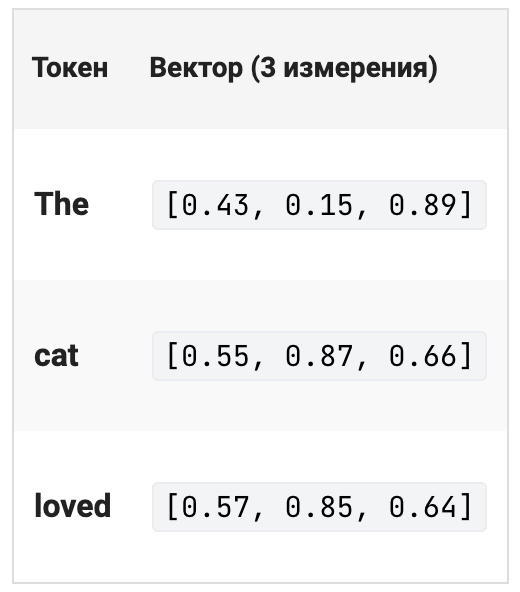

**Матрица входных данных X:**

$$
X =
\begin{bmatrix}
0.43 & 0.15 & 0.89 \\
0.55 & 0.87 & 0.66 \\
0.57 & 0.85 & 0.64
\end{bmatrix}
$$

Строка 0 = The, 

строка 1 = cat, 

строка 2 = loved. 

Три столбца = три измерения вектора.

**Обучаемые весовые матрицы**

Для примера зададим три матрицы весов (в реальности они инициализируются случайными цифрами и в дальнейшем обучаются):

$$
W_Q =
\begin{bmatrix}
0.5 & 0.2 & 0.1 \\
0.3 & 0.6 & 0.2 \\
0.1 & 0.1 & 0.7
\end{bmatrix}
$$

$$
W_K =
\begin{bmatrix}
0.4 & 0.3 & 0.2 \\
0.2 & 0.5 & 0.3 \\
0.3 & 0.2 & 0.6
\end{bmatrix}
$$

$$
W_V =
\begin{bmatrix}
0.6 & 0.1 & 0.2 \\
0.1 & 0.7 & 0.1 \\
0.2 & 0.2 & 0.5
\end{bmatrix}
$$

## Шаг 1: Вычисляем Query, Key, Value

Теперь каждый входной вектор преобразуется через три матрицы весов.

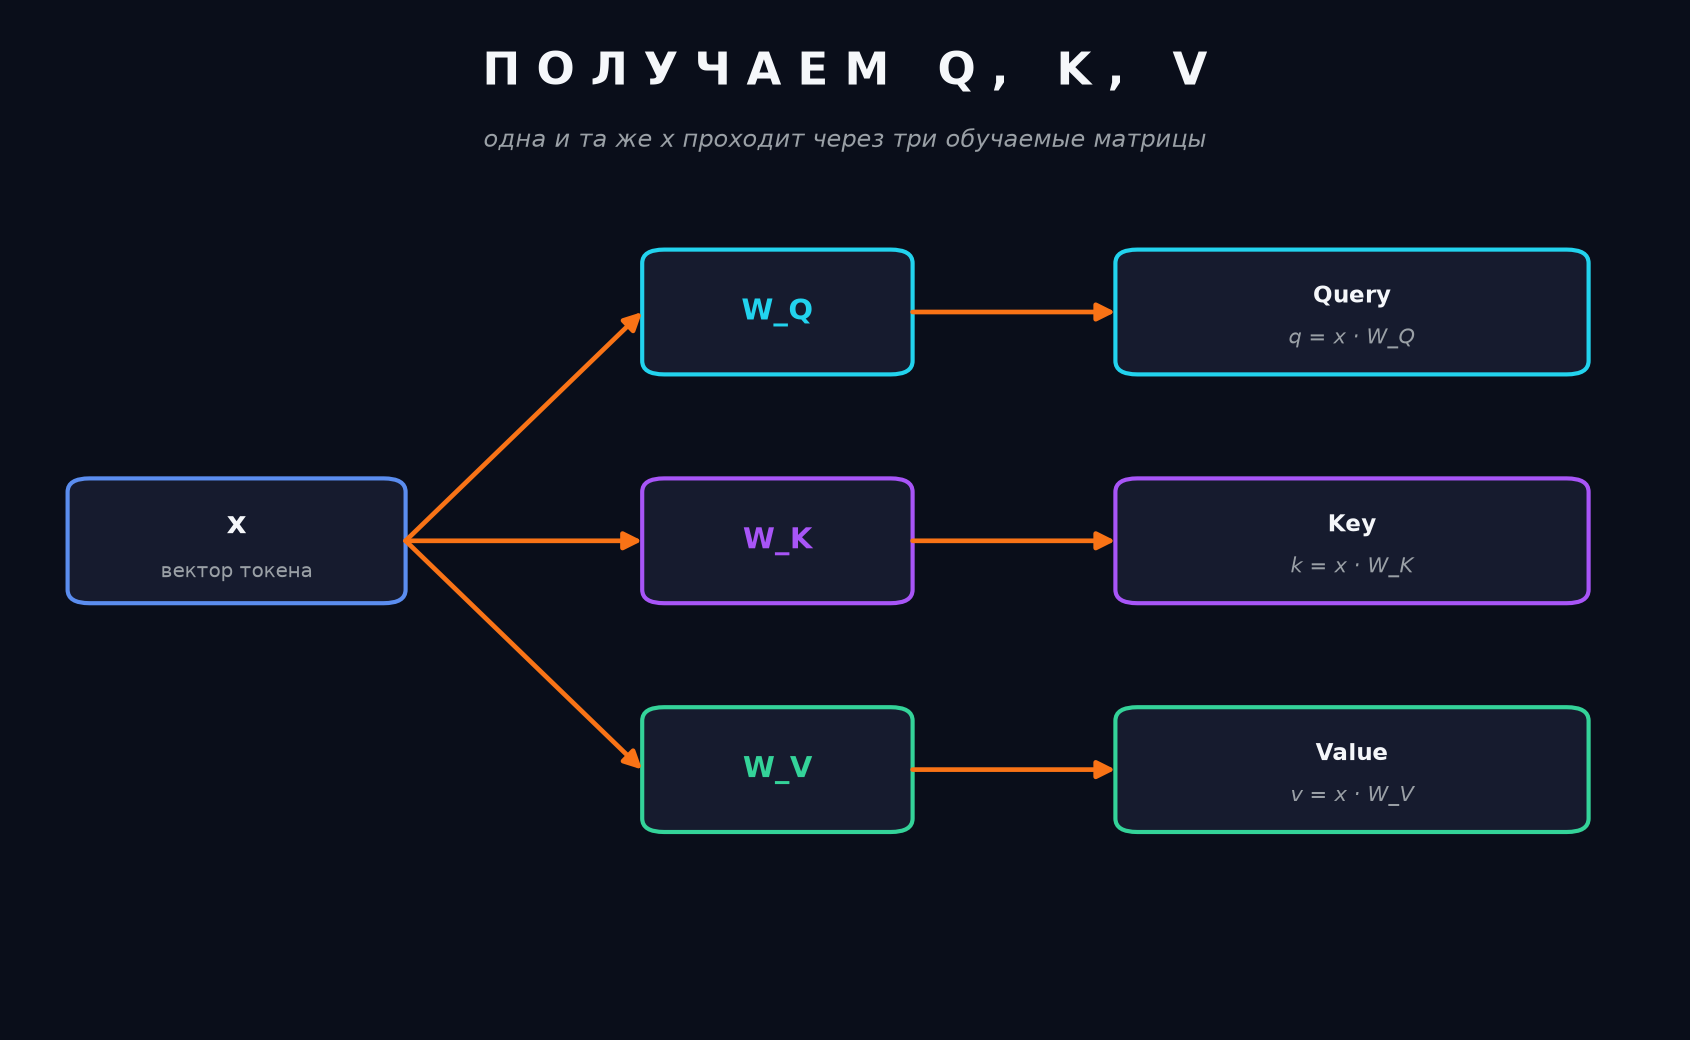

**Формулы**

Для каждого токена i:

- $q_i = x_i \mathbin{@} W_Q$ **(Query вектор)**

- $k_i = x_i \mathbin{@} W_K$ **(Key вектор)**

- $v_i = x_i \mathbin{@} W_V$ **(Value вектор)**

Или можно для всей матрицы сразу:

$$
\begin{aligned}
Q &= X \mathbin{@} W_Q \\
K &= X \mathbin{@} W_K \\
V &= X \mathbin{@} W_V
\end{aligned}
$$

Итак, получаем:

$$
Q =
\begin{bmatrix}
0.349 & 0.265 & 0.696 \\
0.602 & 0.698 & 0.691 \\
0.604 & 0.688 & 0.675
\end{bmatrix}
$$

$$
K =
\begin{bmatrix}
0.469 & 0.382 & 0.665 \\
0.592 & 0.732 & 0.767 \\
0.590 & 0.724 & 0.753
\end{bmatrix}
$$

$$
V =
\begin{bmatrix}
0.451 & 0.326 & 0.546 \\
0.549 & 0.796 & 0.527 \\
0.555 & 0.780 & 0.519
\end{bmatrix}
$$

Теперь вычисляем схожесть между **Query** и **Key** (а не между входными векторами, как раньше).

$$
\mathrm{Scores} = Q \mathbin{@} K^T
$$


$$
\mathrm{Scores} =
\begin{bmatrix}
0.7277 & 0.9344 & 0.9219 \\
1.0084 & 1.3973 & 1.3809 \\
0.9950 & 1.3789 & 1.3628
\end{bmatrix}
$$

**В этом уроке, появляется важная деталь, без которой механизм внимания в языковой модели будет работать формально правильно, но по смыслу - неправильно.**

Это **Causal Mask**

Когда языковая модель читает текст слева направо и учится предсказывать следующий токен, она должна находиться в честных условиях. Если мы сейчас стоим на позиции слова «любил» в фразе:

`«Кот любил сметану»`

то модель может смотреть на:

- «кот»

- «любил»

**но не должна видеть слово «сметану», если именно его мы собираемся предсказать.**

Иначе задача ломается. Модель не учится угадывать следующий токен по прошлому контексту, а начинает просто подглядывать в правильный ответ.

Именно это и запрещает каузальная маска.

Self-attention по своей природе очень свободный механизм. Каждый токен может смотреть на любой другой токен в последовательности. Для задач вроде анализа уже готового текста это нормально: если у нас есть целое предложение, мы действительно можем разрешить словам учитывать и левый, и правый контекст.

**Но в decoder-only LLM, где модель генерирует текст по одному токену за раз, такая свобода уже недопустима.**

Если токен на позиции $t$ увидит токены на позициях $t + 1, t + 2, \ldots$, то модель получит информацию из будущего. А будущего при реальной генерации у неё ещё нет.

Поэтому для авторегрессионной языковой модели действует простое правило: **каждый токен может смотреть только на себя и на токены слева от себя!**

**Где маска вмешивается в вычисления?**

Для формулы attention scores:

$$Scores = \frac{QK^T}{\sqrt{d_k}}$$

Это сырые оценки того, насколько каждый токен должен смотреть на каждый другой.

Каузальная маска добавляется именно здесь, до softmax:

$$MaskedScores = \frac{QK^T}{\sqrt{d_k}} + M$$

$M$ - матрица маски

Почему маска прибавляется, а не умножается?

Потому что дальше идёт softmax. Нам нужно не просто «ослабить» запрещённые связи, а сделать так, чтобы их вероятность стала практически нулевой.

Поэтому в:

* запрещённые позиции маски обычно ставят $-\infty$

* а в разрешённые - 0

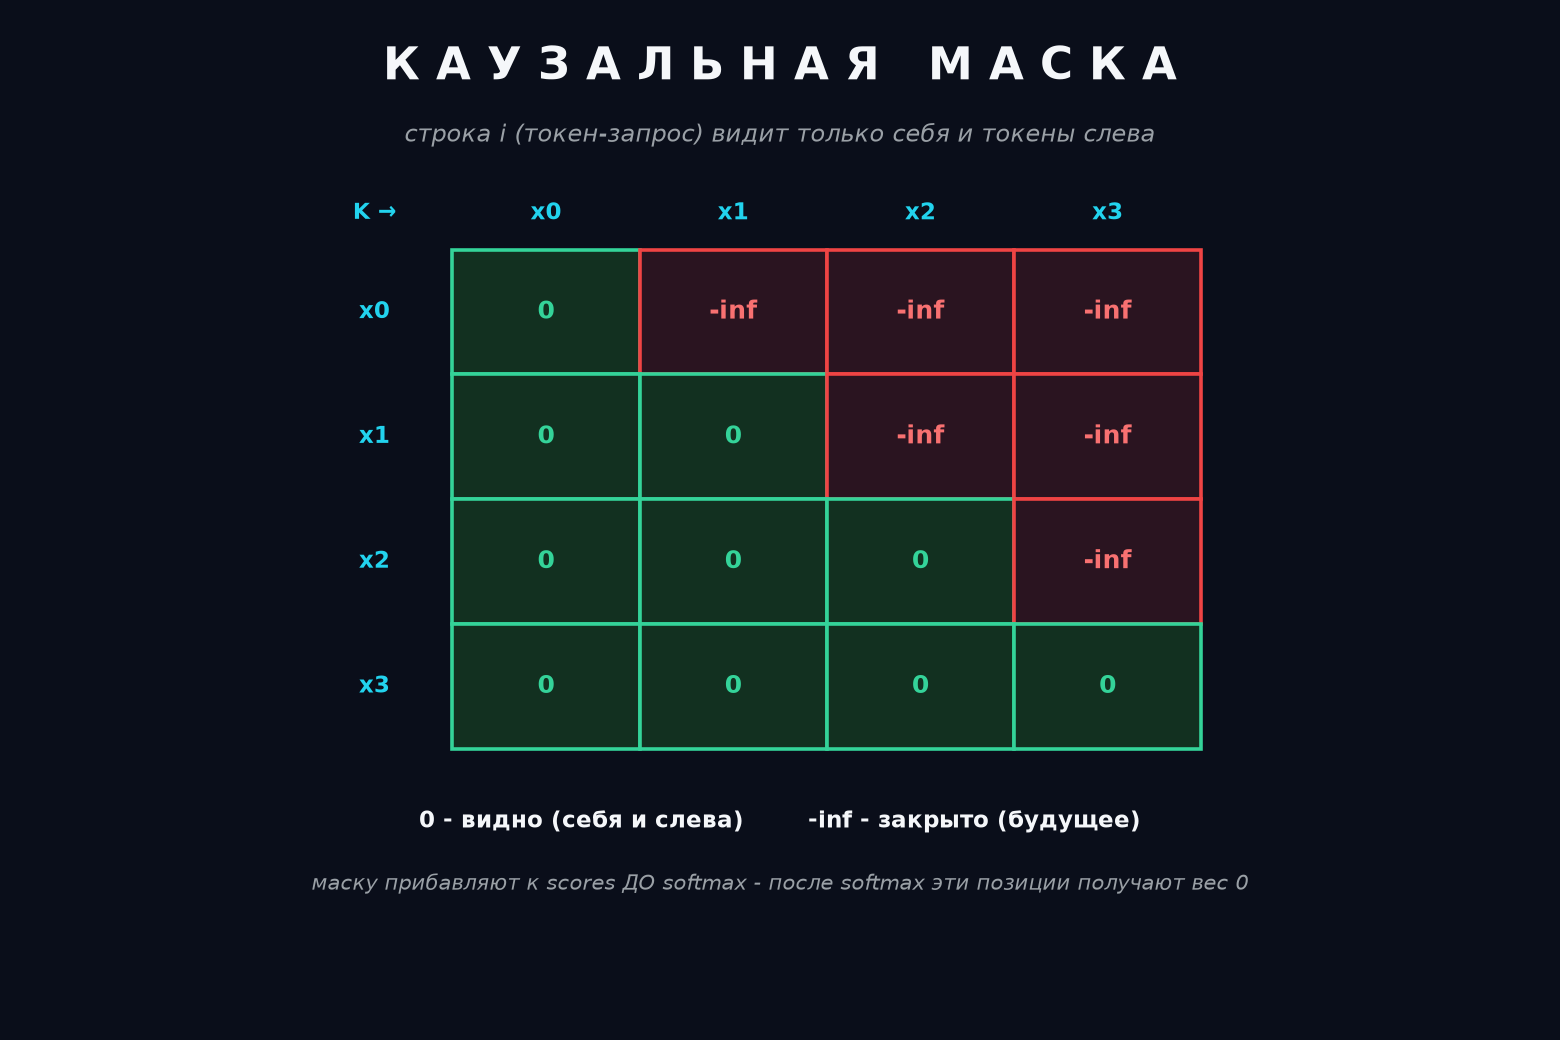

Теперь посмотрим, что происходит. Допустим, до маски у нас была строка scores для второго токена: `[1.2, 0.8, 2.1, 0.5]`

Смысл этой строки такой:

- насколько второй токен смотрит на первый,
- на второй,
- на третий,
- на четвёртый.

Но второй токен не должен видеть третий и четвёртый. Значит, после добавления маски получится:

$$[1.2, 0.8, -\infty, -\infty]$$

Теперь применяем softmax. Все позиции с $-\infty$ превращаются в нулевые вероятности:

$$softmax([1.2, 0.8, -\infty, -\infty]) = [p_1, p_2, 0, 0]$$

То есть attention больше не сможет распределить вес на будущее. Даже если исходный score там был большим, маска жёстко запрещает эту связь.

**Важное замечание перед расчётом: В этом ручном примере мы не применяем каузальную маску и не делим scores на $\sqrt{d_k}$. Мы делаем это специально, чтобы спокойно увидеть и понять базовую механику self-attention: как из входных векторов получаются $Q, K, V$, как считаются scores, как работает  softmax и как формируется итоговый context vector.**

Применяем softmax к каждой строке. Всё так же, как мы и делали раньше, ничего нового.

$$
\mathrm{Weights} =
\begin{bmatrix}
0.2904 & 0.3570 & 0.3526 \\
0.2547 & 0.3757 & 0.3696 \\
0.2556 & 0.3752 & 0.3692
\end{bmatrix}
$$

Отлично, веса рассчитали, теперь можно посчитать контекстные векторы.

**Формула:**

$$Context = Weights@V$$

$$
Z =
\begin{bmatrix}
0.5227 & 0.6539 & 0.5297 \\
0.5263 & 0.6704 & 0.5289 \\
0.5262 & 0.6700 & 0.5289
\end{bmatrix}
$$

В каждой строке находится контекстный вектор соответствующего слова.

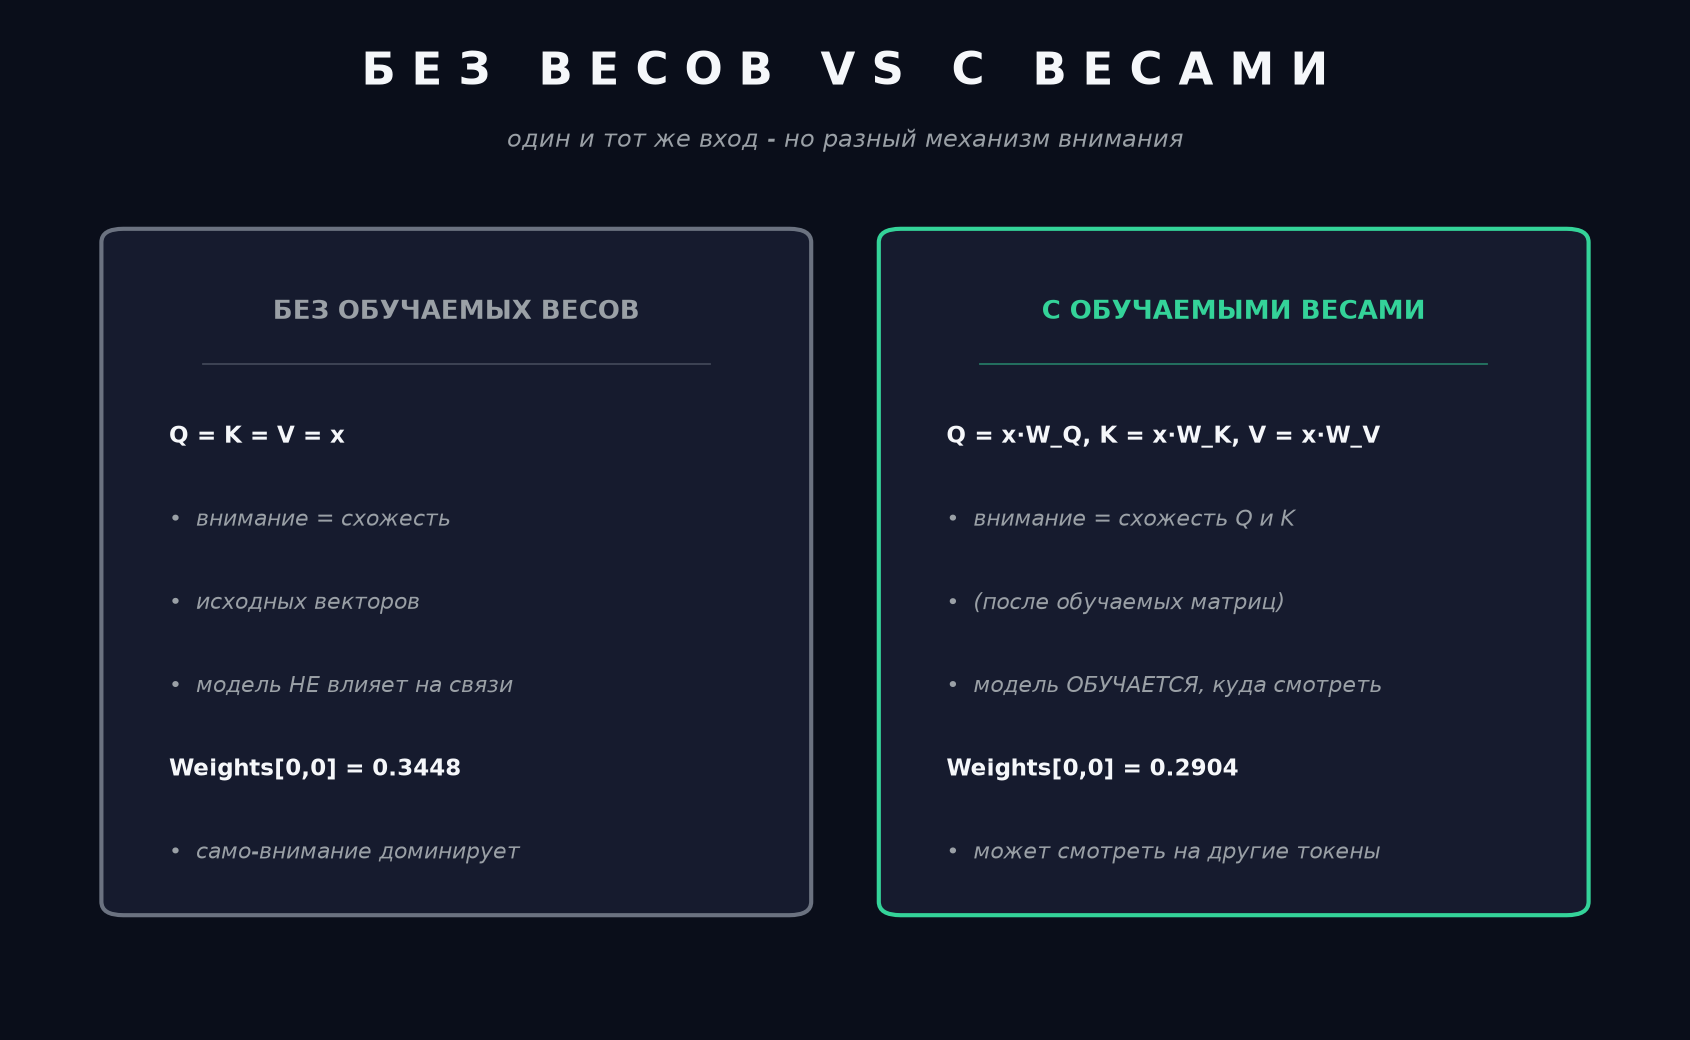

С обучаемыми весами модель может научиться уделять больше внимания другим токенам, а не только себе. Это критически важно для понимания контекста.

Всю математику мы разобрали вручную. Теперь запишем то же самое на Python - но уже с обучаемыми матрицами $W_Q, W_K, W_V$.